In [ ]:
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
torch.manual_seed(123)

## Problem Overview: Cauchy-Euler Equation

We are using a Physics-Informed Neural Network (PINN) to solve the following second-order differential equation:

$$x^2 \frac{d^2y}{dx^2} + 3x \frac{dy}{dx} + y = 0$$

### Domain and Conditions
- **Domain**: $x \in [1, 2]$
- **Initial Conditions**: $y(1) = 3$ and $y'(1) = -4$

### Exact Solution
The analytical solution for this specific problem is:
$$y(x) = \frac{1}{x}(3-logx)$$

In [ ]:
def exact_solution(x):
    """
    Defines the analytical solution
    """
    return 1/x * (3 - torch.log(x))

class FCN(nn.Module):
    """
    Defines a fully-connected network in PyTorch
    """
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = nn.Tanh
        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation()])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation()]) for _ in range(N_LAYERS-1)])
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

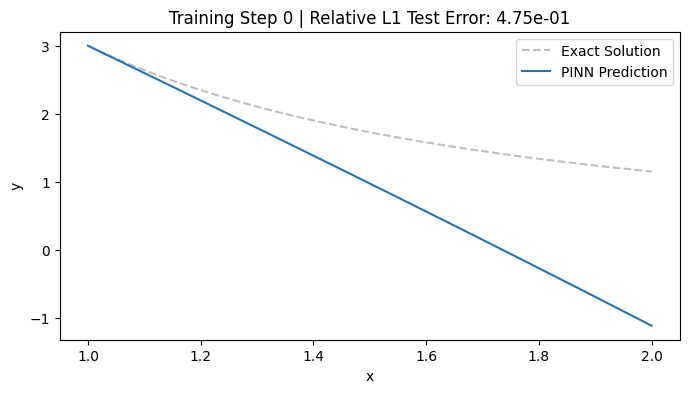

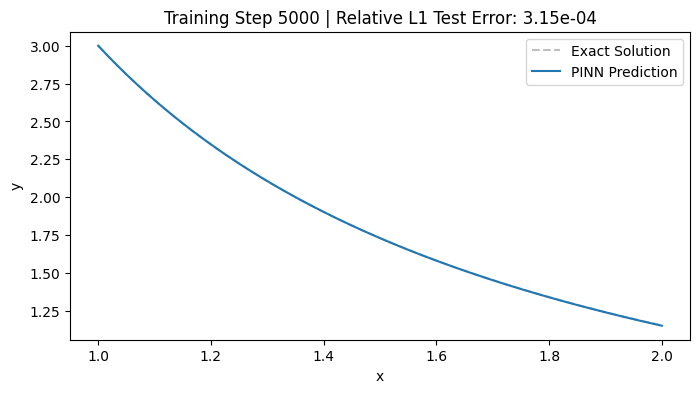

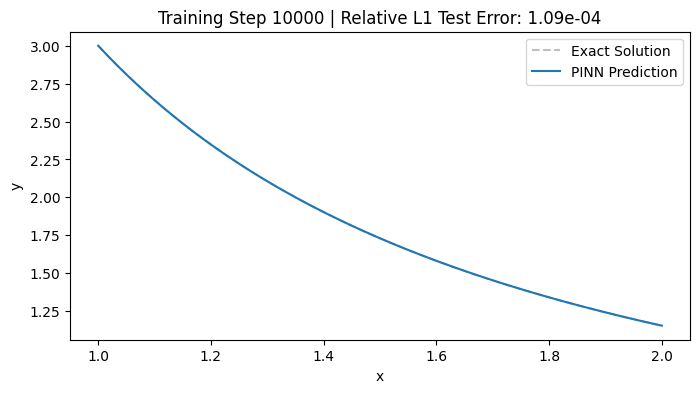

Total training time: 29.19 seconds


In [ ]:
# 1. Setup Network and Data
pinn = FCN(1, 1, 32, 3) # Input: x, Output: y

# Define boundary point (x=1)
x_boundary = torch.tensor([[1.0]], requires_grad=True)

# Define collocation points for physics loss (x in [1, 2])
x_physics = torch.linspace(1, 2, 30).view(-1, 1).requires_grad_(True)

# For evaluation
x_test = torch.linspace(1, 2, 300).view(-1, 1)
y_exact = exact_solution(x_test)

optimiser = torch.optim.Adam(pinn.parameters(), lr=1e-3)

# 2. Training Loop
start_time = time.time()
for i in range(10001):
    optimiser.zero_grad()

    # --- Physics Loss ---
    # Equation: x^2*y'' + 3x*y' + y = 0
    y = pinn(x_physics)
    dydx = torch.autograd.grad(y, x_physics, torch.ones_like(y), create_graph=True)[0]
    d2ydx2 = torch.autograd.grad(dydx, x_physics, torch.ones_like(dydx), create_graph=True)[0]

    # --- Hard-Embedding Trial Form ---
    # u(t) = u0 + v0*t + t^2 * f(t)
    # Adjusted for x_boundary = 1: y = 3 + (-4)*(x-1) + (x-1)^2 * pinn(x)
    y0, v0 = 3.0, -4.0
    t = x_physics - 1.0  # Shifted coordinate

    y = pinn(x_physics)
    y_pred = y0 + (v0 * t) + (t**2 * y)

    # --- Physics Loss (Automatic Differentiation) ---
    # PyTorch handles the complex product rule for y', y'' automatically
    dydx = torch.autograd.grad(y_pred, x_physics, torch.ones_like(y_pred), create_graph=True)[0]
    d2ydx2 = torch.autograd.grad(dydx, x_physics, torch.ones_like(dydx), create_graph=True)[0]

    # Residual: x^2*y'' + 3x*y' + y = 0
    physics_residual = (x_physics**2 * d2ydx2) + (3 * x_physics * dydx) + y_pred
    loss = torch.mean(physics_residual**2)

    loss.backward()
    optimiser.step()

    # 3. Visualization
    if i % 5000 == 0:
        # You must apply the trial form to the test data for the plot to be correct
        t_test = x_test - 1.0
        y_pred = (y0 + (v0 * t_test) + (t_test**2 * pinn(x_test))).detach()
        # Calculate relative L1 test error
        relative_l1_error = torch.sum(torch.abs(y_pred - y_exact)) / torch.sum(torch.abs(y_exact))

        plt.figure(figsize=(8, 4))
        plt.plot(x_test, y_exact, label="Exact Solution", color="grey", alpha=0.5, linestyle="--")
        plt.plot(x_test, y_pred, label="PINN Prediction", color="tab:blue")
        plt.title(f"Training Step {i} | Relative L1 Test Error: {relative_l1_error.item():.2e}")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time() - start_time:.2f} seconds")

## Task 2: Training a PINN to Invert for Underlying Parameters

#### The Objective
In the previous simulation task, we assumed all physical constants were known. In many real-world scenarios, we observe the behavior of a system but do not know the underlying physical properties.

In this **inverse problem**, we reverse the logic:
* **Inputs**: Noisy observations of the displacement $y$ at various points $x$.
* **Outputs**: An estimate for the unknown coefficient in the differential equation.

We assume our Cauchy-Euler equation takes the following form, where $\alpha$ is an unknown parameter:
$$x^2 \frac{d^2y}{dx^2} + \alpha x \frac{dy}{dx} + y = 0$$

The true value is **3.0**. We will see if the PINN can "discover" this value from noisy data (generated from the initial conditions $y(1)=3$ and $y'(1)=-4$) starting from an initial guess of **0.0**.

#### The Approach
Unlike standard neural networks, we treat $\alpha$ as a **learnable parameter** (specifically a `torch.nn.Parameter` in PyTorch or a separate optimized array in JAX).

The optimization process happens in two directions simultaneously:
1. The network weights $\theta$ are updated to fit the observed data points.
2. The parameter $\alpha$ is updated to make the resulting curve consistent with the physics residual.

#### Loss Function for Inversion
The loss function is a weighted sum of the physics consistency and the data matching:

$$L(\theta, \alpha) = \mathcal{L}_{\mathrm{physics}} + \lambda \mathcal{L}_{\mathrm{data}}$$

$$L(\theta, \alpha) = \frac{1}{N} \sum^{N}_{i} \left( x_i^2 \hat{y}'' + \alpha x_i \hat{y}' + \hat{y} \right)^2 + \frac{\lambda}{M} \sum^{M}_{j} \left( \hat{y}(x_j, \theta) - y_{\mathrm{obs}}(x_j) \right)^2$$

* **Physics Loss**: Ensures the solution obeys the structure of the differential equation.
* **Data Loss**: Forces the solution to pass through the noisy experimental observations and the known boundary points ($x=1$).

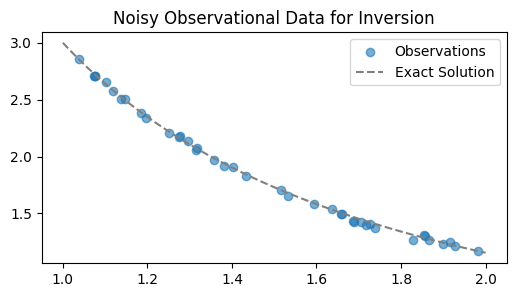

In [ ]:
# 1. Create noisy observational data
torch.manual_seed(123)
# The true value we want to recover is -2.0
true_alpha = 3.0

# Generate 40 random points in the domain [1, 2]
x_obs = (1 + torch.rand(40)).view(-1,1)
# Calculate exact y values and add Gaussian noise
y_obs = exact_solution(x_obs) + 0.02 * torch.randn_like(x_obs)

# For plotting
x_test = torch.linspace(1, 2, 300).view(-1, 1)
y_exact = exact_solution(x_test)

plt.figure(figsize=(6, 3))
plt.title("Noisy Observational Data for Inversion")
plt.scatter(x_obs.detach(), y_obs.detach(), label="Observations", alpha=0.6)
plt.plot(x_test, y_exact, label="Exact Solution", color="grey", linestyle="--")
plt.legend()
plt.show()

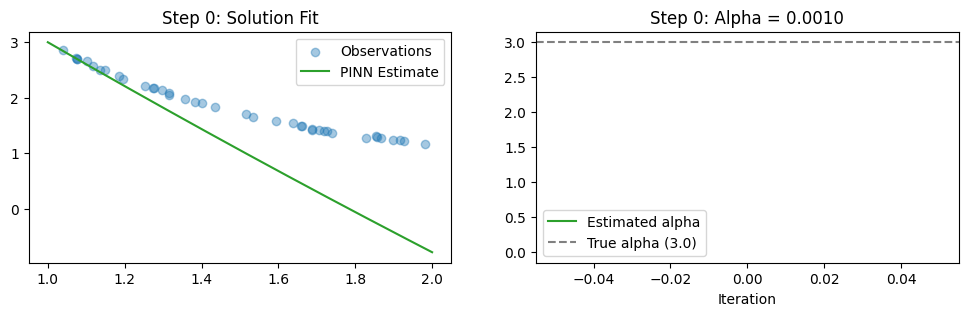

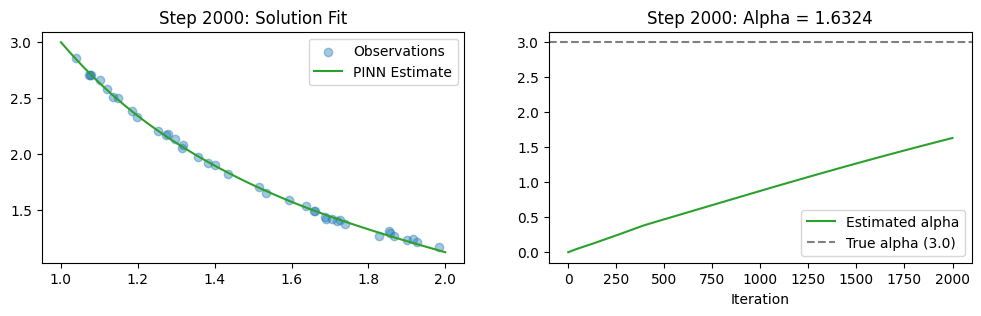

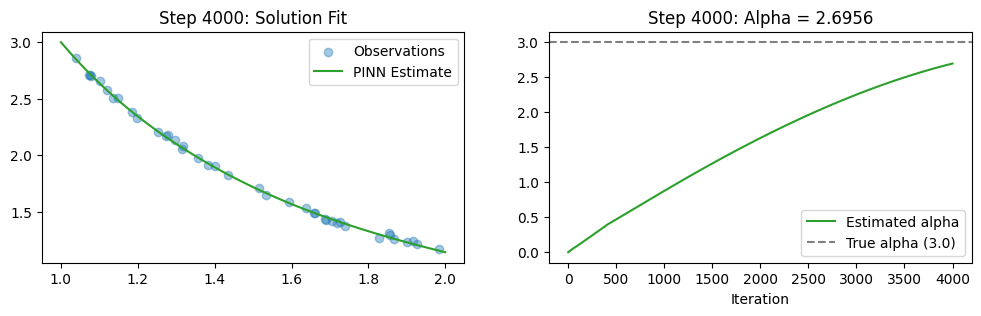

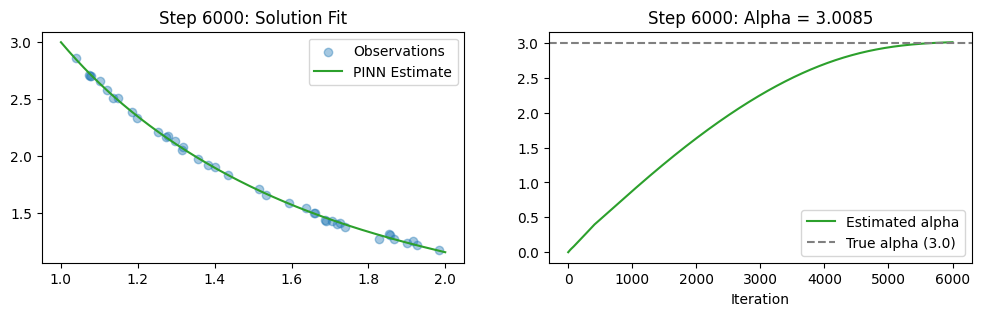

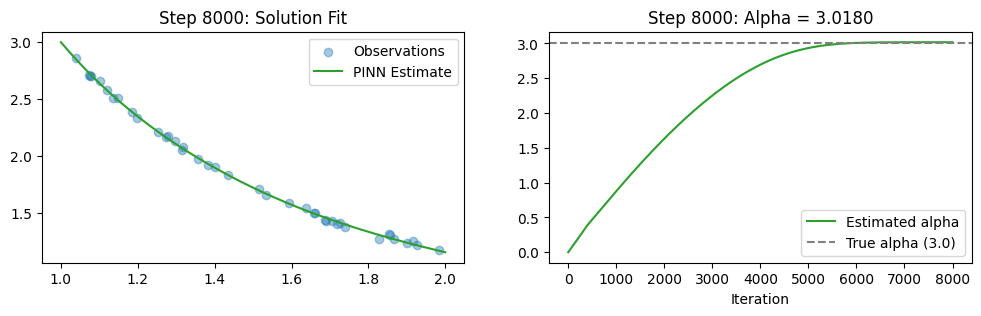

Total training time: 26.53 seconds
Final estimated alpha: 3.0180


In [ ]:
# 1. Setup Network and the Unknown Parameter
pinn_inv = FCN(1, 1, 32, 3)

# Initialize alpha with a guess (e.g., 0.0). The true value is 3.0.
alpha = nn.Parameter(torch.zeros(1, requires_grad=True))

# Define collocation points for the physics loss
x_physics = torch.linspace(1, 2, 50).view(-1, 1).requires_grad_(True)

# Add both PINN weights and the unknown parameter alpha to the optimizer
optimiser = torch.optim.Adam(list(pinn_inv.parameters()) + [alpha], lr=1e-3)

# 2. Training Loop
alphas = []
start_time = time.time()

for i in range(8001):
    optimiser.zero_grad()

    # --- Hard-Embedding Trial Form (Physics Points) ---
    y0, v0 = 3.0, -4.0
    t_phy = x_physics - 1.0  # Shift boundary x=1 to t=0

    # Trial form: y = y0 + v0*t + t^2 * f(t)
    nn_phy = pinn_inv(x_physics)
    y_phy_pred = y0 + (v0 * t_phy) + (t_phy**2 * nn_phy)

    # Compute derivatives of the trial form
    dydx = torch.autograd.grad(y_phy_pred, x_physics, torch.ones_like(y_phy_pred), create_graph=True)[0]
    d2ydx2 = torch.autograd.grad(dydx, x_physics, torch.ones_like(dydx), create_graph=True)[0]

    # Equation: x^2*y'' + alpha*x*y' + y = 0
    res = (x_physics**2 * d2ydx2) + (alpha * x_physics * dydx) + y_phy_pred
    loss_physics = torch.mean(res**2)

    # --- Data Loss (Using Trial Form) ---
    t_obs = x_obs - 1.0
    nn_obs = pinn_inv(x_obs)
    y_obs_pred = y0 + (v0 * t_obs) + (t_obs**2 * nn_obs)

    # Minimize difference with noisy observations
    loss_data = torch.mean((y_obs_pred - y_obs)**2)

    # Total Loss (lambda balances physics consistency with data fit)
    lambda_data = 1e4
    loss = loss_physics + lambda_data * loss_data

    loss.backward()
    optimiser.step()

    alphas.append(alpha.item())

    # 3. Visualization
    if i % 2000 == 0:
        # --- Visualization Update ---
        t_test = x_test - 1.0
        y_test_pred = (y0 + (v0 * t_test) + (t_test**2 * pinn_inv(x_test))).detach()

        plt.figure(figsize=(12, 3))
        # Subplot 1: Solution Fit
        plt.subplot(1, 2, 1)
        plt.scatter(x_obs.detach(), y_obs.detach(), alpha=0.4, label="Observations")
        plt.plot(x_test, y_test_pred, color="tab:green", label="PINN Estimate")
        plt.title(f"Step {i}: Solution Fit")
        plt.legend()

        # Subplot 2: Parameter Convergence
        plt.subplot(1, 2, 2)
        plt.plot(alphas, color="tab:green", label="Estimated alpha")
        plt.axhline(y=true_alpha, color="grey", linestyle="--", label="True alpha (3.0)")
        plt.title(f"Step {i}: Alpha = {alpha.item():.4f}")
        plt.xlabel("Iteration")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time() - start_time:.2f} seconds")
print(f"Final estimated alpha: {alpha.item():.4f}")